# PhillyStat360 — 04c: Final Model vs. City of Philadelphia VPI

> Add blockquote



Compares our final ensemble model (`ensemble_prob` from 04a) against the City of Philadelphia's **Vacant Property Indicator (VPI)** — specifically the *Vacant Indicators Bldg* layer published on OpenDataPhilly.

**Source:** `https://hub.arcgis.com/api/v3/datasets/f7ed68293c5e40d58f1de9c8435c3e84_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1`

The City's VPI dataset only contains parcels the City has *flagged as vacant*. So a parcel is `vpi_flag = 1` if it appears in the VPI download, else `0`. The City also publishes a continuous `build_rank` (Buildings: Vacancy Rank) for the flagged parcels, which we use as the City's ranking score on its own subset.

**Residential cleaning.** The VPI dataset mixes residential, commercial, industrial, and miscellaneous structures. We restrict to residential by joining VPI parcels to the OPA `category_code_description` and keeping only `SINGLE FAMILY`, `MULTI FAMILY`, `MIXED USE`, and `APARTMENTS > 4 UNITS` — the same residential definition used in 04a/04b.

**Ground truth.** Both models are evaluated against `ovs` (the Office of Vacant Strategies label) from `predictions_04b.csv`.

## 0. Setup

In [24]:
# Mount Google Drive (run once per Colab session). Comment out if running locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — using local paths.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os
from pathlib import Path

if IN_COLAB:
    ROOT = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
else:
    # Local Windows path — adjust if your working directory differs.
    ROOT = Path('G:/My Drive/PhillyStat_R/PhillyStat360')

RAW_PATH   = ROOT / 'rawdata'
DATA_PATH  = ROOT / 'data'
PY_PATH    = ROOT / 'data_py'
OUT_PATH   = ROOT / 'data_py'
GRAPH_PATH = ROOT / 'graphs' / 'python'

OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)

assert (PY_PATH / 'predictions_04b.csv').exists(), \
    f'predictions_04b.csv not found at {PY_PATH}. Run 04b_vpi_comparison.ipynb first.'
print('Paths OK. ROOT =', ROOT)

Paths OK. ROOT = /content/drive/MyDrive/PhillyStat_R/PhillyStat360


In [26]:
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix)

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

## 1. Load our final-model predictions

`predictions_04b.csv` is already restricted to residential parcels (single-family, multi-family, mixed use, apartments > 4 units) and carries the calibrated `ensemble_prob` plus `ovs` ground truth.

In [27]:
preds = pd.read_csv(PY_PATH / 'predictions_04b.csv', low_memory=False)
preds['parcel_number'] = preds['parcel_number'].astype(str).str.strip()

RESIDENTIAL_CATS = {'SINGLE FAMILY', 'MULTI FAMILY', 'MIXED USE', 'APARTMENTS  > 4 UNITS'}
before = len(preds)
preds = preds[preds['category_code_description'].isin(RESIDENTIAL_CATS)].copy()
print(f"Final-model residential parcels: {len(preds):,} (dropped {before - len(preds):,} non-residential)")
print(f"  ovs prevalence: {preds['ovs'].mean():.3%}")
preds.head(3)

Final-model residential parcels: 520,196 (dropped 0 non-residential)
  ovs prevalence: 1.141%


,parcel_number,ovs,data_split,ensemble_prob,prob_tier,zip_code,geographic_ward,census_tract,category_code,category_code_description
0,661269500,0,train,0.001250,Very Unlikely (0–0.2),19114.0,66.0,353.0,1,SINGLE FAMILY
1,888115554,0,train,0.000478,Very Unlikely (0–0.2),19107.0,5.0,9.0,1,SINGLE FAMILY
2,622111000,0,train,0.001204,Very Unlikely (0–0.2),19124.0,62.0,300.0,1,SINGLE FAMILY


## 2. Download the City's VPI dataset

The download is cached locally as `rawdata/vpi_bldg.geojson` so re-runs are instant.

In [28]:
VPI_URL = ('https://hub.arcgis.com/api/v3/datasets/'
           'f7ed68293c5e40d58f1de9c8435c3e84_0/downloads/data'
           '?format=geojson&spatialRefId=4326&where=1%3D1')
VPI_PATH = RAW_PATH / 'vpi_bldg.geojson'
RAW_PATH.mkdir(parents=True, exist_ok=True)

if not VPI_PATH.exists():
    print(f"Downloading VPI dataset â†’ {VPI_PATH} ...")
    urllib.request.urlretrieve(VPI_URL, VPI_PATH)
    print(f"  done ({VPI_PATH.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Using cached {VPI_PATH} ({VPI_PATH.stat().st_size / 1e6:.1f} MB)")

Using cached /content/drive/MyDrive/PhillyStat_R/PhillyStat360/rawdata/vpi_bldg.geojson (6.4 MB)


In [29]:
import json

with open(VPI_PATH, 'r', encoding='utf-8') as f:
    gj = json.load(f)

vpi = pd.DataFrame([feat['properties'] for feat in gj['features']])
vpi.columns = [c.lower() for c in vpi.columns]
print(f"VPI raw rows: {len(vpi):,}")
print(f"VPI columns: {list(vpi.columns)}")
vpi.head(3)

VPI raw rows: 8,048
VPI columns: ['objectid', 'address', 'owner1', 'owner2', 'bldg_desc', 'opa_id', 'lniaddresskey', 'councildistrict', 'zoningbasedistrict', 'zipcode', 'build_rank', 'date_update', 'shape__area', 'shape__length']


,objectid,address,owner1,owner2,bldg_desc,opa_id,lniaddresskey,councildistrict,zoningbasedistrict,zipcode,build_rank,date_update,shape__area,shape__length
0,186,2525 S BEULAH ST,BARR DENNIS,None,ROW 2 STY MASONRY,393201000,38207,1,RSA-5,19148,0.500000,2026-04-26T00:00:00Z,110.164062,50.673702
1,201,5651 N 16TH ST,ODUD NATALIYA,LASKAVY MAXIM,ROW B/GAR 2STY MASONRY,172125300,661423,8,RSA-5,19141,0.500000,2026-04-26T00:00:00Z,395.414062,93.491704
2,363,3137 KENSINGTON AVE,KENZO FIX LLC,None,STORE 3 STY MASONRY,882038710,368836,7,CMX-2.5,19134,0.666667,2026-04-26T00:00:00Z,178.257812,67.783864


## 3. Clean VPI â†’ residential only

Three cleaning steps:
1. Drop rows with no `opa_id` (cannot match anything).
2. Restrict to residential by joining with OPA `category_code_description` and keeping the four residential categories.
3. Deduplicate to one row per parcel (keep the row with the highest `build_rank` if there are duplicates).

In [30]:
# 3a. Standardize opa_id and drop missing
vpi['opa_id'] = vpi['opa_id'].astype(str).str.strip()
vpi = vpi[vpi['opa_id'].ne('') & vpi['opa_id'].ne('nan') & vpi['opa_id'].notna()]
print(f"VPI rows with opa_id: {len(vpi):,}")

# 3b. Pull category code from OPA so we apply the same residential filter as 04a/04b
opa_path = RAW_PATH / 'opa_properties_public.csv'
opa = pd.read_csv(opa_path, low_memory=False, usecols=['parcel_number',
                                                       'category_code',
                                                       'category_code_description'])
opa.columns = [c.lower() for c in opa.columns]
opa['parcel_number'] = opa['parcel_number'].astype(str).str.strip()
opa = opa.drop_duplicates(subset='parcel_number')

vpi_res = (
    vpi.merge(opa, left_on='opa_id', right_on='parcel_number', how='left')
       .loc[lambda d: d['category_code_description'].isin(RESIDENTIAL_CATS)]
)
print(f"VPI âˆ© residential: {len(vpi_res):,} rows ({len(vpi_res)/len(vpi):.1%} of all VPI)")

# 3c. Deduplicate (keep highest build_rank per parcel)
if 'build_rank' in vpi_res.columns:
    vpi_res['build_rank'] = pd.to_numeric(vpi_res['build_rank'], errors='coerce')
    vpi_res = (
        vpi_res.sort_values('build_rank', ascending=False, na_position='last')
               .drop_duplicates(subset='opa_id', keep='first')
    )
print(f"VPI residential, deduped: {len(vpi_res):,} parcels")

vpi_res[['opa_id', 'address', 'bldg_desc', 'category_code_description', 'build_rank',
         'zipcode']].head(5)

VPI rows with opa_id: 8,048
VPI âˆ© residential: 6,418 rows (79.7% of all VPI)
VPI residential, deduped: 6,418 parcels


,opa_id,address,bldg_desc,category_code_description,build_rank,zipcode
7966,233037100,945 FOULKROD ST,SEMI DET 2 STY MASONRY,SINGLE FAMILY,1.0,19124
29,251009400,2708 E SOMERSET ST,ROW 2 STY MASONRY,SINGLE FAMILY,1.0,19134
3029,401313400,6034 GREENWAY AVE,SEMI DET 2 STY MASONRY,SINGLE FAMILY,1.0,19142
3410,323225600,2154 N NEWKIRK ST,ROW 2 STY MASONRY,SINGLE FAMILY,1.0,19121
76,403328200,7238 PASCHALL AVE,ROW 2 STY MASONRY,SINGLE FAMILY,1.0,19142


In [31]:
# Sanity check: how does the residential split look in VPI vs all-VPI?
split_summary = (
    vpi.merge(opa, left_on='opa_id', right_on='parcel_number', how='left')
       ['category_code_description'].fillna('UNMATCHED').value_counts().head(15)
)
print('Top building categories in raw VPI download:')
print(split_summary)

Top building categories in raw VPI download:
category_code_description
SINGLE FAMILY                    5377
UNMATCHED                         884
MULTI FAMILY                      598
MIXED USE                         400
VACANT LAND                       354
COMMERCIAL                        259
INDUSTRIAL                        109
APARTMENTS  > 4 UNITS              43
VACANT LAND - RESIDENTIAL           7
VACANT LAND - NON-RESIDENTIAL       5
OFFICES                             5
GARAGE - COMMERCIAL                 3
GARAGE - RESIDENTIAL                2
RETAIL                              1
HOTEL                               1
Name: count, dtype: int64


## 4. Build the head-to-head frame

Left-join the residential VPI flag onto our residential predictions. Every parcel in `preds` gets `vpi_flag` = 1 if VPI has it listed, else 0. Parcels in VPI residential that aren't in our prediction set are dropped — we can only score the parcels both models scored.

In [32]:
vpi_keep = vpi_res[['opa_id', 'build_rank']].rename(columns={'opa_id': 'parcel_number'})
vpi_keep['vpi_flag'] = 1

df = preds.merge(vpi_keep, on='parcel_number', how='left')
df['vpi_flag']   = df['vpi_flag'].fillna(0).astype(int)
df['build_rank'] = df['build_rank']  # NaN for non-VPI parcels (they have no City score)

# Coverage on each side
n_total       = len(df)
n_ovs         = int(df['ovs'].sum())
n_vpi         = int(df['vpi_flag'].sum())
n_vpi_in_pred = df['parcel_number'].isin(vpi_res['opa_id']).sum()
n_vpi_only    = len(vpi_res) - n_vpi_in_pred

print(f"Residential parcels (our scope): {n_total:,}")
print(f"  ovs = 1 (ground truth vacant): {n_ovs:,} ({n_ovs/n_total:.2%})")
print(f"  vpi_flag = 1 (City flagged):   {n_vpi:,} ({n_vpi/n_total:.2%})")
print(f"  VPI residential parcels NOT in our prediction set: {n_vpi_only:,}")

Residential parcels (our scope): 520,196
  ovs = 1 (ground truth vacant): 5,934 (1.14%)
  vpi_flag = 1 (City flagged):   6,410 (1.23%)
  VPI residential parcels NOT in our prediction set: 8


## 5. Head-to-head metrics

VPI is a **binary** classifier (in the list or not). Our model is **continuous** (`ensemble_prob`). For an apples-to-apples binary comparison, threshold the ensemble at the level that produces the same number of positives as VPI — this controls for prevalence and lets us compare precision/recall directly. Then we also report AUC for our model (which VPI cannot give us).

In [33]:
y      = df['ovs'].astype(int).values
p_ours = df['ensemble_prob'].values
v_vpi  = df['vpi_flag'].values

def binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall    = tp / (tp + fn) if (tp + fn) else np.nan
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan
    return dict(n_pos=int((y_pred == 1).sum()), tp=int(tp), fp=int(fp), fn=int(fn),
                precision=precision, recall=recall, f1=f1)

# Match-prevalence threshold for our model: pick the top-N highest probs where N = #VPI positives
N = int(v_vpi.sum())
thresh = np.sort(p_ours)[::-1][N - 1]  # boundary value
p_ours_bin = (p_ours >= thresh).astype(int)

rows = []
rows.append({'model': 'City VPI (binary)', **binary_metrics(y, v_vpi)})
rows.append({'model': f'Ours @ matched prevalence (thresh={thresh:.3f})',
             **binary_metrics(y, p_ours_bin)})
rows.append({'model': 'Ours @ 0.5 threshold',     **binary_metrics(y, (p_ours >= 0.5).astype(int))})
compare = pd.DataFrame(rows)
compare.round(4)

,model,n_pos,tp,fp,fn,precision,recall,f1
0,City VPI (binary),6410,3416,2994,2518,0.5329,0.5757,0.5535
1,Ours @ matched prevalence (thresh=0.191),8499,4645,3854,1289,0.5465,0.7828,0.6437
2,Ours @ 0.5 threshold,3606,3265,341,2669,0.9054,0.5502,0.6845


In [34]:
# Continuous metrics our model gets that VPI cannot (VPI is binary across the population)
auc_ours = roc_auc_score(y, p_ours)
ap_ours  = average_precision_score(y, p_ours)

# Treat VPI as a degenerate score for a fair AUC: AUC of a binary prediction = (TPR + TNR) / 2 = balanced accuracy
auc_vpi  = roc_auc_score(y, v_vpi)
ap_vpi   = average_precision_score(y, v_vpi)

print(f"AUC  — Our model: {auc_ours:.4f}   |  City VPI (binary): {auc_vpi:.4f}")
print(f"PR-AUC — Our model: {ap_ours:.4f}   |  City VPI (binary): {ap_vpi:.4f}")

AUC  — Our model: 0.9786   |  City VPI (binary): 0.7849
PR-AUC — Our model: 0.7538   |  City VPI (binary): 0.3116


## 6. Confusion matrix between the two models

Where do the City and our model agree/disagree, and which is closer to ground truth?

In [35]:
agreement = pd.crosstab(
    pd.Series(v_vpi,        name='City VPI'),
    pd.Series(p_ours_bin,   name='Our model (matched prev.)'),
)
print('Agreement matrix (parcel counts):')
print(agreement)

# Among disagreements, which model's call matches ovs more often?
disagree = (v_vpi != p_ours_bin)
vpi_right = ((v_vpi == y) & disagree).sum()
ours_right = ((p_ours_bin == y) & disagree).sum()
print(f"\nDisagreements: {int(disagree.sum()):,}")
print(f"  City VPI right, our model wrong: {int(vpi_right):,}")
print(f"  Our model right, City VPI wrong: {int(ours_right):,}")

Agreement matrix (parcel counts):
Our model (matched prev.)       0     1
City VPI                               
0                          508486  5300
1                            3211  3199

Disagreements: 8,511
  City VPI right, our model wrong: 4,071
  Our model right, City VPI wrong: 4,440


## 7. ROC and PR curves

Our model produces full ROC/PR curves. The City's binary VPI shows up as a single operating point.

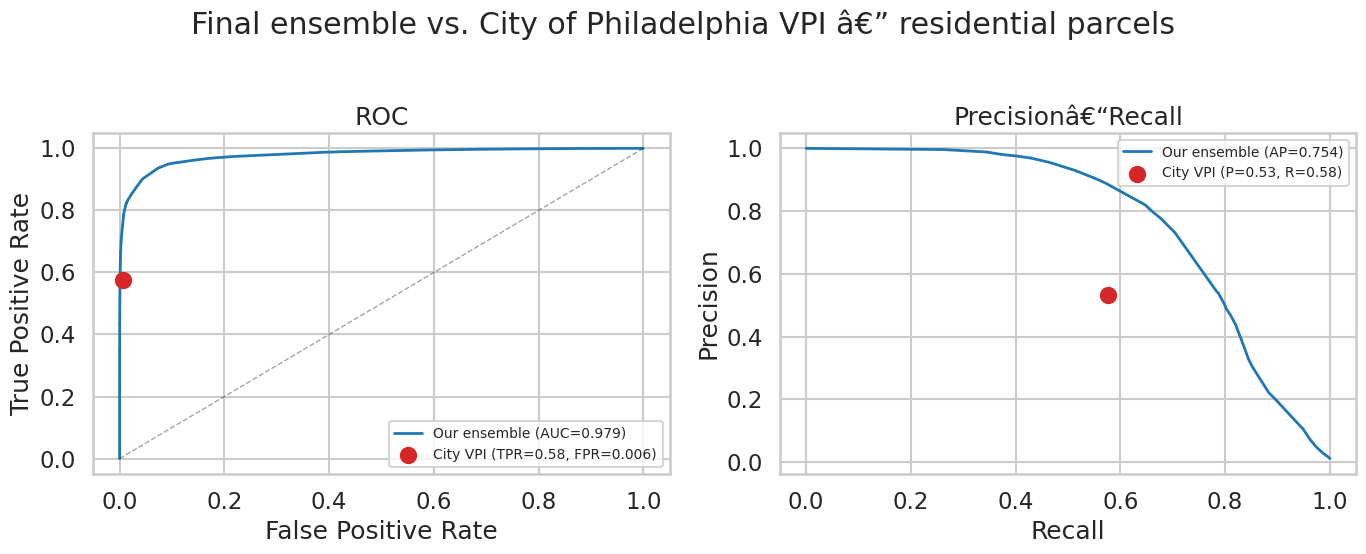

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
fpr, tpr, _ = roc_curve(y, p_ours)
axes[0].plot(fpr, tpr, lw=2, label=f'Our ensemble (AUC={auc_ours:.3f})', color='#1f77b4')
fpr_v, tpr_v, _ = roc_curve(y, v_vpi)
axes[0].scatter(fpr_v[1], tpr_v[1], color='#d62728', s=120, zorder=5,
                label=f'City VPI (TPR={tpr_v[1]:.2f}, FPR={fpr_v[1]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC')
axes[0].legend(loc='lower right', fontsize=10)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y, p_ours)
axes[1].plot(rec, prec, lw=2, label=f'Our ensemble (AP={ap_ours:.3f})', color='#1f77b4')
vpi_metrics = binary_metrics(y, v_vpi)
axes[1].scatter(vpi_metrics['recall'], vpi_metrics['precision'], color='#d62728', s=120, zorder=5,
                label=f"City VPI (P={vpi_metrics['precision']:.2f}, R={vpi_metrics['recall']:.2f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall')
axes[1].legend(loc='upper right', fontsize=10)

fig.suptitle('Final ensemble vs. City of Philadelphia VPI — residential parcels', y=1.02)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'vs_city_vpi_roc_pr.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Where do the two models diverge?

Four buckets for every residential parcel: both flag, only ours flags, only VPI flags, neither flags. Within each bucket, what's the ovs rate?

In [37]:
df['bucket'] = np.select(
    [
        (p_ours_bin == 1) & (v_vpi == 1),
        (p_ours_bin == 1) & (v_vpi == 0),
        (p_ours_bin == 0) & (v_vpi == 1),
        (p_ours_bin == 0) & (v_vpi == 0),
    ],
    ['Both flag', 'Only ours flags', 'Only VPI flags', 'Neither flags'],
    default='?'
)

bucket_summary = (
    df.groupby('bucket')
      .agg(n_parcels=('ovs', 'size'),
           n_ovs=('ovs', 'sum'),
           ovs_rate=('ovs', 'mean'),
           mean_ensemble_prob=('ensemble_prob', 'mean'))
      .reindex(['Both flag', 'Only ours flags', 'Only VPI flags', 'Neither flags'])
      .reset_index()
)
bucket_summary.round(4)

,bucket,n_parcels,n_ovs,ovs_rate,mean_ensemble_prob
0,Both flag,3199,2665,0.8331,0.6084
1,Only ours flags,5300,1980,0.3736,0.4338
2,Only VPI flags,3211,751,0.2339,0.0346
3,Neither flags,508486,538,0.0011,0.0045


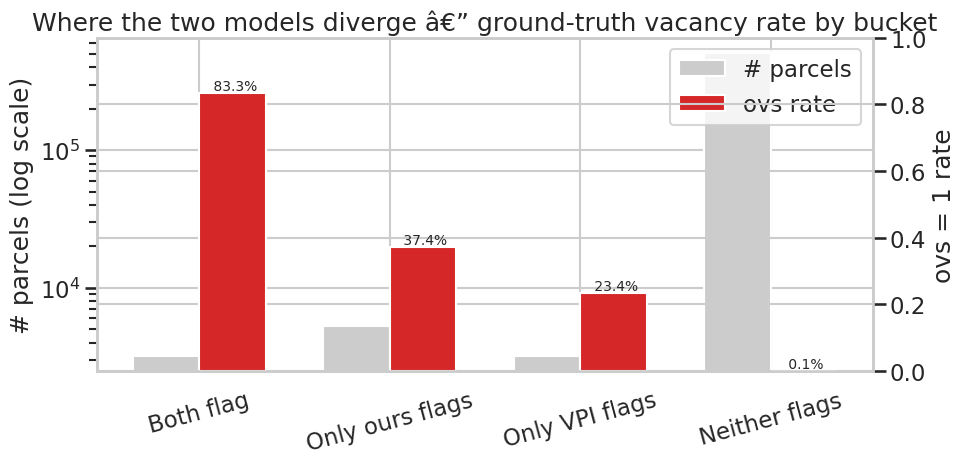

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bucket_summary))
w = 0.35

ax.bar(x - w/2, bucket_summary['n_parcels'], width=w,
       label='# parcels', color='#cccccc')
ax.set_yscale('log')
ax.set_ylabel('# parcels (log scale)')
ax.set_xticks(x)
ax.set_xticklabels(bucket_summary['bucket'], rotation=15)

ax2 = ax.twinx()
ax2.bar(x + w/2, bucket_summary['ovs_rate'], width=w,
        label='ovs rate', color='#d62728')
ax2.set_ylabel('ovs = 1 rate')
ax2.set_ylim(0, 1)
for xi, val in zip(x + w/2, bucket_summary['ovs_rate']):
    ax2.text(xi, val, f' {val:.1%}', va='bottom', ha='center', fontsize=10)

ax.set_title('Where the two models diverge” ground-truth vacancy rate by bucket')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'vs_city_vpi_buckets.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Per-ZIP comparison

Side-by-side: count flagged by each model, and the precision (`flagged & ovs=1` / `flagged`) per ZIP.

In [39]:
df['ours_bin'] = p_ours_bin

zip_compare = (
    df.dropna(subset=['zip_code'])
      .groupby('zip_code')
      .agg(n_parcels=('ovs', 'size'),
           n_ovs=('ovs', 'sum'),
           n_vpi=('vpi_flag', 'sum'),
           n_ours=('ours_bin', 'sum'),
           tp_vpi=('ovs',     lambda s: int(((s == 1) & (df.loc[s.index, 'vpi_flag'] == 1)).sum())),
           tp_ours=('ovs',    lambda s: int(((s == 1) & (df.loc[s.index, 'ours_bin'] == 1)).sum())),
           )
      .reset_index()
)
zip_compare['precision_vpi']  = zip_compare['tp_vpi']  / zip_compare['n_vpi'].replace(0, np.nan)
zip_compare['precision_ours'] = zip_compare['tp_ours'] / zip_compare['n_ours'].replace(0, np.nan)
zip_compare['recall_vpi']     = zip_compare['tp_vpi']  / zip_compare['n_ovs'].replace(0, np.nan)
zip_compare['recall_ours']    = zip_compare['tp_ours'] / zip_compare['n_ovs'].replace(0, np.nan)

zip_compare = zip_compare[zip_compare['n_ovs'] >= 5].sort_values('n_parcels', ascending=False)
print(f"ZIPs with â‰¥5 ovs positives: {len(zip_compare)}")
zip_compare.head(15).round(3)

ZIPs with â‰¥5 ovs positives: 41


,zip_code,n_parcels,n_ovs,n_vpi,n_ours,tp_vpi,tp_ours,precision_vpi,precision_ours,recall_vpi,recall_ours
35,19143.0,23461,515,432,878,270,431,0.625,0.491,0.524,0.837
26,19134.0,21910,567,503,890,348,478,0.692,0.537,0.614,0.843
16,19124.0,20749,190,258,245,126,143,0.488,0.584,0.663,0.753
12,19120.0,20655,147,258,230,98,107,0.380,0.465,0.667,0.728
40,19148.0,20472,132,113,112,65,72,0.575,0.643,0.492,0.545
32,19140.0,18805,484,531,850,313,413,0.589,0.486,0.647,0.853
38,19146.0,18702,147,149,163,70,101,0.470,0.620,0.476,0.687
6,19111.0,18479,48,48,34,28,30,0.583,0.882,0.583,0.625
41,19149.0,17984,40,58,35,27,24,0.466,0.686,0.675,0.600
37,19145.0,17827,137,153,138,84,85,0.549,0.616,0.613,0.620


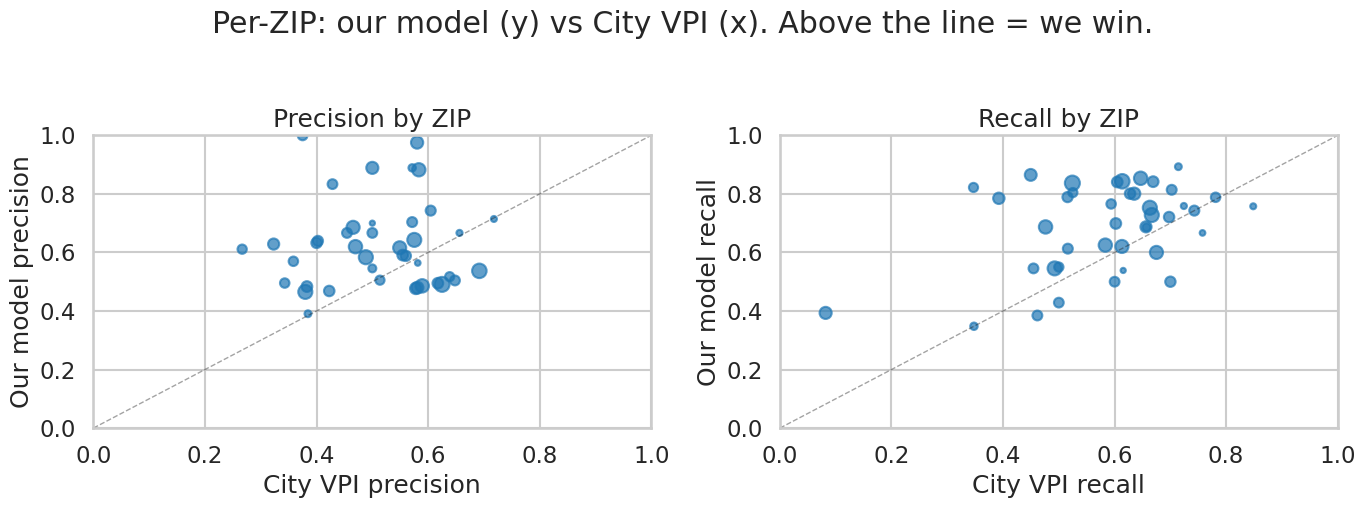

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], 'precision', 'Precision by ZIP'),
    (axes[1], 'recall',    'Recall by ZIP'),
]:
    ax.scatter(zip_compare[f'{metric}_vpi'], zip_compare[f'{metric}_ours'],
               alpha=0.7, s=zip_compare['n_parcels'] / 200, color='#1f77b4')
    lims = [0, 1]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'City VPI {metric}')
    ax.set_ylabel(f'Our model {metric}')
    ax.set_title(title)
fig.suptitle('Per-ZIP: our model (y) vs City VPI (x). Above the line = we win.', y=1.03)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'vs_city_vpi_zip_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Map: where each model flags parcels

Three interactive layers (toggle in the layer control):

- **Both flag** — agreement between our model and City VPI
- **Only ours flags** — our model says vacant, City does not
- **Only VPI flags** — City says vacant, our model does not

To keep the HTML light we render parcel centroids (one circle per parcel), color-coded by bucket. Centroids come from the VPI geojson (for any parcel in VPI) and from `data_py/vacancy_predictions.geojson` (for parcels not in VPI).


In [41]:
# 10a. Pull centroids from the VPI geojson (covers Both + Only-VPI buckets)
def feature_centroid(geom):
    """Return (lon, lat) centroid for a Point/Polygon/MultiPolygon GeoJSON geometry."""
    if geom is None:
        return (np.nan, np.nan)
    t = geom.get("type")
    if t == "Point":
        x, y = geom["coordinates"][:2]
        return (x, y)
    if t == "Polygon":
        ring = geom["coordinates"][0]
        xs = [pt[0] for pt in ring]; ys = [pt[1] for pt in ring]
        return (sum(xs)/len(xs), sum(ys)/len(ys))
    if t == "MultiPolygon":
        xs, ys, n = 0.0, 0.0, 0
        for poly in geom["coordinates"]:
            for pt in poly[0]:
                xs += pt[0]; ys += pt[1]; n += 1
        return (xs/n, ys/n) if n else (np.nan, np.nan)
    return (np.nan, np.nan)

vpi_xy = []
for feat in gj["features"]:
    props = feat.get("properties", {})
    opa = str(props.get("opa_id", "") or "").strip()
    if not opa:
        continue
    lon, lat = feature_centroid(feat.get("geometry"))
    vpi_xy.append((opa, lon, lat))
vpi_xy = pd.DataFrame(vpi_xy, columns=["parcel_number", "lon", "lat"]).drop_duplicates("parcel_number")
print(f"VPI centroids: {len(vpi_xy):,}")


VPI centroids: 8,043


In [42]:
# 10b. Pull centroids from our predictions geojson — only for parcels still needed
# (Only-ours-flags bucket: in our model but not in VPI)
need_ours = set(df.loc[df["bucket"] == "Only ours flags", "parcel_number"])
need_ours -= set(vpi_xy["parcel_number"])
print(f"Centroids still needed for Only-ours-flags bucket: {len(need_ours):,}")

ours_xy = {}
preds_geo_path = PY_PATH / "vacancy_predictions.geojson"
if need_ours and preds_geo_path.exists():
    try:
        import ijson
        with open(preds_geo_path, "r", encoding="utf-8") as f:
            for feat in ijson.items(f, "features.item"):
                pid = str(feat.get("properties", {}).get("parcel_number", "") or "").strip()
                if pid in need_ours and pid not in ours_xy:
                    lon, lat = feature_centroid(feat.get("geometry"))
                    ours_xy[pid] = (lon, lat)
                    if len(ours_xy) >= len(need_ours):
                        break
    except ImportError:
        print("ijson not available; falling back to geopandas (slower, more memory).")
        import geopandas as gpd
        gdf = gpd.read_file(preds_geo_path)
        gdf["parcel_number"] = gdf["parcel_number"].astype(str).str.strip()
        gdf = gdf[gdf["parcel_number"].isin(need_ours)].copy()
        cents = gdf.geometry.centroid
        for pid, x, y in zip(gdf["parcel_number"], cents.x, cents.y):
            ours_xy[pid] = (x, y)

ours_xy_df = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in ours_xy.items()],
    columns=["parcel_number", "lon", "lat"],
)
print(f"Resolved Only-ours centroids: {len(ours_xy_df):,}")


Centroids still needed for Only-ours-flags bucket: 5,300
ijson not available; falling back to geopandas (slower, more memory).
Resolved Only-ours centroids: 4,158


In [43]:
# 10c. Attach lon/lat to df for the three flagged buckets
xy_all = pd.concat([vpi_xy, ours_xy_df], ignore_index=True).drop_duplicates("parcel_number")
df_xy  = df.merge(xy_all, on="parcel_number", how="left")

flagged_mask = df_xy["bucket"].isin(["Both flag", "Only ours flags", "Only VPI flags"])
df_map = df_xy[flagged_mask & df_xy["lon"].notna() & df_xy["lat"].notna()].copy()

print("Parcels mapped per bucket:")
print(df_map["bucket"].value_counts())
missing = df_xy[flagged_mask & df_xy["lon"].isna()]["bucket"].value_counts()
if len(missing):
    print("\nFlagged parcels missing geometry (not mapped):")
    print(missing)


Parcels mapped per bucket:
bucket
Only ours flags    4158
Only VPI flags     3211
Both flag          3199
Name: count, dtype: int64

Flagged parcels missing geometry (not mapped):
bucket
Only ours flags    1142
Name: count, dtype: int64


In [44]:
# 10d. Build the interactive folium map
import folium
from folium.plugins import MarkerCluster

BUCKET_COLOR = {
    "Both flag":       "#7b3294",  # purple — agreement
    "Only ours flags": "#1f78b4",  # blue   — our model only
    "Only VPI flags":  "#e31a1c",  # red    — City only
}

m = folium.Map(location=[39.9526, -75.1652], zoom_start=12, tiles="cartodbpositron")

for bucket in ["Both flag", "Only ours flags", "Only VPI flags"]:
    sub = df_map[df_map["bucket"] == bucket]
    if sub.empty:
        continue
    fg = folium.FeatureGroup(name=f"{bucket}  (n={len(sub):,})", show=True)
    color = BUCKET_COLOR[bucket]
    container = MarkerCluster(disableClusteringAtZoom=15) if len(sub) > 1500 else fg
    for _, row in sub.iterrows():
        popup_html = (
            f"<b>Parcel:</b> {row['parcel_number']}<br>"
            f"<b>Bucket:</b> {bucket}<br>"
            f"<b>ovs (truth):</b> {int(row['ovs'])}<br>"
            f"<b>Our prob:</b> {row['ensemble_prob']:.3f}<br>"
            f"<b>VPI flag:</b> {int(row['vpi_flag'])}<br>"
            f"<b>Build rank:</b> {row['build_rank'] if pd.notna(row['build_rank']) else '—'}<br>"
            f"<b>ZIP:</b> {row.get('zip_code', '')}"
        )
        folium.CircleMarker(
            location=(row["lat"], row["lon"]),
            radius=3, color=color, weight=0,
            fill=True, fill_color=color, fill_opacity=0.7,
            popup=folium.Popup(popup_html, max_width=300),
        ).add_to(container)
    if container is not fg:
        container.add_to(fg)
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style='position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; padding: 10px 14px; border: 1px solid #999;
            font-size: 13px; box-shadow: 0 1px 4px rgba(0,0,0,0.2);'>
  <b>Model agreement</b><br>
  <span style='display:inline-block;width:10px;height:10px;background:#7b3294;border-radius:50%;margin-right:6px;'></span>Both flag<br>
  <span style='display:inline-block;width:10px;height:10px;background:#1f78b4;border-radius:50%;margin-right:6px;'></span>Only ours flags<br>
  <span style='display:inline-block;width:10px;height:10px;background:#e31a1c;border-radius:50%;margin-right:6px;'></span>Only VPI flags
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = OUT_PATH / "vs_city_vpi_map.html"
m.save(str(map_path))
print(f"Map saved -> {map_path}")
m


Output hidden; open in https://colab.research.google.com to view.

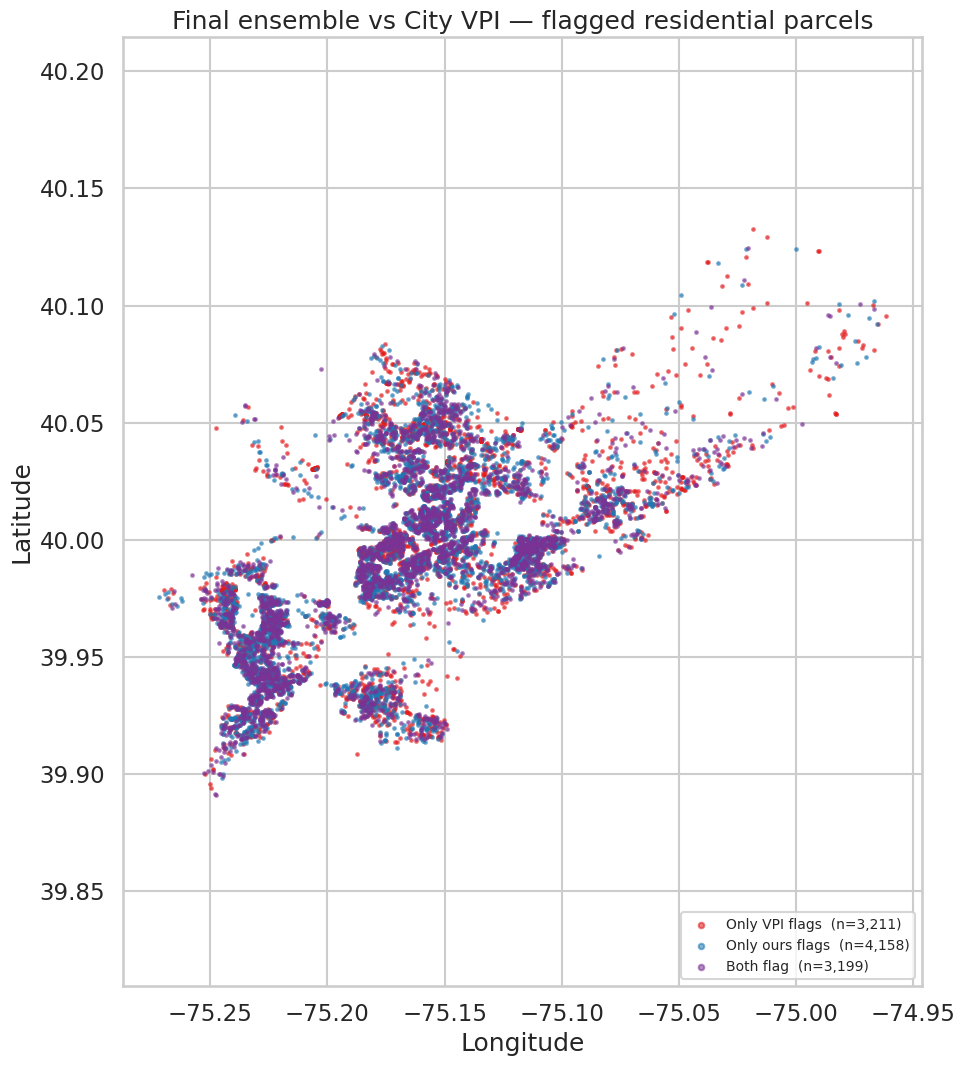

In [45]:
# 10e. Static matplotlib version (one PNG, no JS dependencies)
fig, ax = plt.subplots(figsize=(10, 11))
order = ["Only VPI flags", "Only ours flags", "Both flag"]  # draw agreement on top
for bucket in order:
    sub = df_map[df_map["bucket"] == bucket]
    ax.scatter(sub["lon"], sub["lat"], s=4, alpha=0.55,
               color=BUCKET_COLOR[bucket],
               label=f"{bucket}  (n={len(sub):,})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Final ensemble vs City VPI — flagged residential parcels")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(loc="lower right", fontsize=10, markerscale=2)
plt.tight_layout()
plt.savefig(GRAPH_PATH / "vs_city_vpi_map.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Map: highest model probability where OVS = 0

These are parcels our model is most confident are vacant, yet the OVS ground truth says they are *not* vacant — i.e. our model's most assertive disagreements with OVS. Worth investigating: they're either model false positives, or genuinely vacant parcels that OVS is missing.

Circle radius scales with `ensemble_prob` (larger = higher predicted probability).


In [46]:
# 11a. Build the candidate set: ovs=0, sorted by ensemble_prob descending
TOP_N = 1000      # hard cap so the map stays responsive
PROB_FLOOR = 0.4  # don't bother showing low-prob parcels

fp = (
    df.loc[(df["ovs"] == 0) & (df["ensemble_prob"] >= PROB_FLOOR)]
      .sort_values("ensemble_prob", ascending=False)
      .head(TOP_N)
      .copy()
)
print(f"High-prob OVS=0 parcels selected: {len(fp):,}  (threshold={PROB_FLOOR}, cap={TOP_N})")

# Resolve centroids — reuse xy_all where possible, then fill gaps from the predictions geojson
fp = fp.merge(xy_all, on="parcel_number", how="left")
need = set(fp.loc[fp["lon"].isna(), "parcel_number"])
print(f"  centroids already known: {len(fp) - len(need):,}; still need: {len(need):,}")

extra_xy = {}
preds_geo_path = PY_PATH / "vacancy_predictions.geojson"
if need and preds_geo_path.exists():
    try:
        import ijson
        with open(preds_geo_path, "r", encoding="utf-8") as f:
            for feat in ijson.items(f, "features.item"):
                pid = str(feat.get("properties", {}).get("parcel_number", "") or "").strip()
                if pid in need and pid not in extra_xy:
                    lon, lat = feature_centroid(feat.get("geometry"))
                    extra_xy[pid] = (lon, lat)
                    if len(extra_xy) >= len(need):
                        break
    except ImportError:
        import geopandas as gpd
        gdf = gpd.read_file(preds_geo_path)
        gdf["parcel_number"] = gdf["parcel_number"].astype(str).str.strip()
        gdf = gdf[gdf["parcel_number"].isin(need)].copy()
        cents = gdf.geometry.centroid
        for pid, x, y in zip(gdf["parcel_number"], cents.x, cents.y):
            extra_xy[pid] = (x, y)

if extra_xy:
    extra_df = pd.DataFrame(
        [(k, v[0], v[1]) for k, v in extra_xy.items()],
        columns=["parcel_number", "lon_new", "lat_new"],
    )
    fp = fp.merge(extra_df, on="parcel_number", how="left")
    fp["lon"] = fp["lon"].fillna(fp["lon_new"])
    fp["lat"] = fp["lat"].fillna(fp["lat_new"])
    fp = fp.drop(columns=["lon_new", "lat_new"])

fp_map = fp.dropna(subset=["lon", "lat"]).copy()
print(f"  centroids resolved: {len(fp_map):,}")
fp_map[["parcel_number", "ensemble_prob", "vpi_flag", "zip_code"]].head(10)


High-prob OVS=0 parcels selected: 423  (threshold=0.4, cap=1000)
  centroids already known: 339; still need: 84
  centroids resolved: 339


,parcel_number,ensemble_prob,vpi_flag,zip_code
0,342206900,1.000000,0,19151.0
1,342160900,1.000000,0,19151.0
2,121103400,1.000000,0,19144.0
3,513201300,1.000000,0,19143.0
5,112093100,1.000000,0,19140.0
6,441205200,0.946429,0,19139.0
7,603138100,0.946429,0,19139.0
9,291058500,0.946429,0,19121.0
10,403310700,0.946429,0,19142.0
13,463277800,0.946429,0,19143.0


In [47]:
# 11b. Interactive folium map — circle radius scales with ensemble_prob
import folium

m_fp = folium.Map(location=[39.9526, -75.1652], zoom_start=12, tiles="cartodbpositron")

# Linear radius scaling: 4..16 px across the visible probability range
p_min = fp_map["ensemble_prob"].min()
p_max = fp_map["ensemble_prob"].max()
def radius_for(p):
    if p_max == p_min:
        return 8
    return 4 + 12 * (p - p_min) / (p_max - p_min)

for _, row in fp_map.iterrows():
    popup_html = (
        f"<b>Parcel:</b> {row['parcel_number']}<br>"
        f"<b>Our prob:</b> {row['ensemble_prob']:.3f}<br>"
        f"<b>OVS truth:</b> 0<br>"
        f"<b>VPI flag:</b> {int(row['vpi_flag'])}<br>"
        f"<b>Build rank:</b> {row['build_rank'] if pd.notna(row['build_rank']) else '—'}<br>"
        f"<b>Bucket:</b> {row['bucket']}<br>"
        f"<b>ZIP:</b> {row.get('zip_code', '')}"
    )
    # Color by whether the City also flagged it (corroboration vs purely-our call)
    color = "#7b3294" if row["vpi_flag"] == 1 else "#1f78b4"
    folium.CircleMarker(
        location=(row["lat"], row["lon"]),
        radius=radius_for(row["ensemble_prob"]),
        color=color, weight=0.5,
        fill=True, fill_color=color, fill_opacity=0.55,
        popup=folium.Popup(popup_html, max_width=300),
    ).add_to(m_fp)

legend_html = f"""
<div style='position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; padding: 10px 14px; border: 1px solid #999;
            font-size: 13px; box-shadow: 0 1px 4px rgba(0,0,0,0.2);'>
  <b>High-prob OVS=0 parcels</b><br>
  Top {len(fp_map):,} by ensemble_prob (≥{PROB_FLOOR})<br>
  Radius = ensemble_prob<br><br>
  <span style='display:inline-block;width:10px;height:10px;background:#7b3294;border-radius:50%;margin-right:6px;'></span>VPI also flags<br>
  <span style='display:inline-block;width:10px;height:10px;background:#1f78b4;border-radius:50%;margin-right:6px;'></span>Only our model
</div>"""
m_fp.get_root().html.add_child(folium.Element(legend_html))

fp_map_path = OUT_PATH / "vs_city_vpi_high_prob_ovs0_map.html"
m_fp.save(str(fp_map_path))
print(f"Map saved -> {fp_map_path}")
m_fp


Map saved -> /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_high_prob_ovs0_map.html


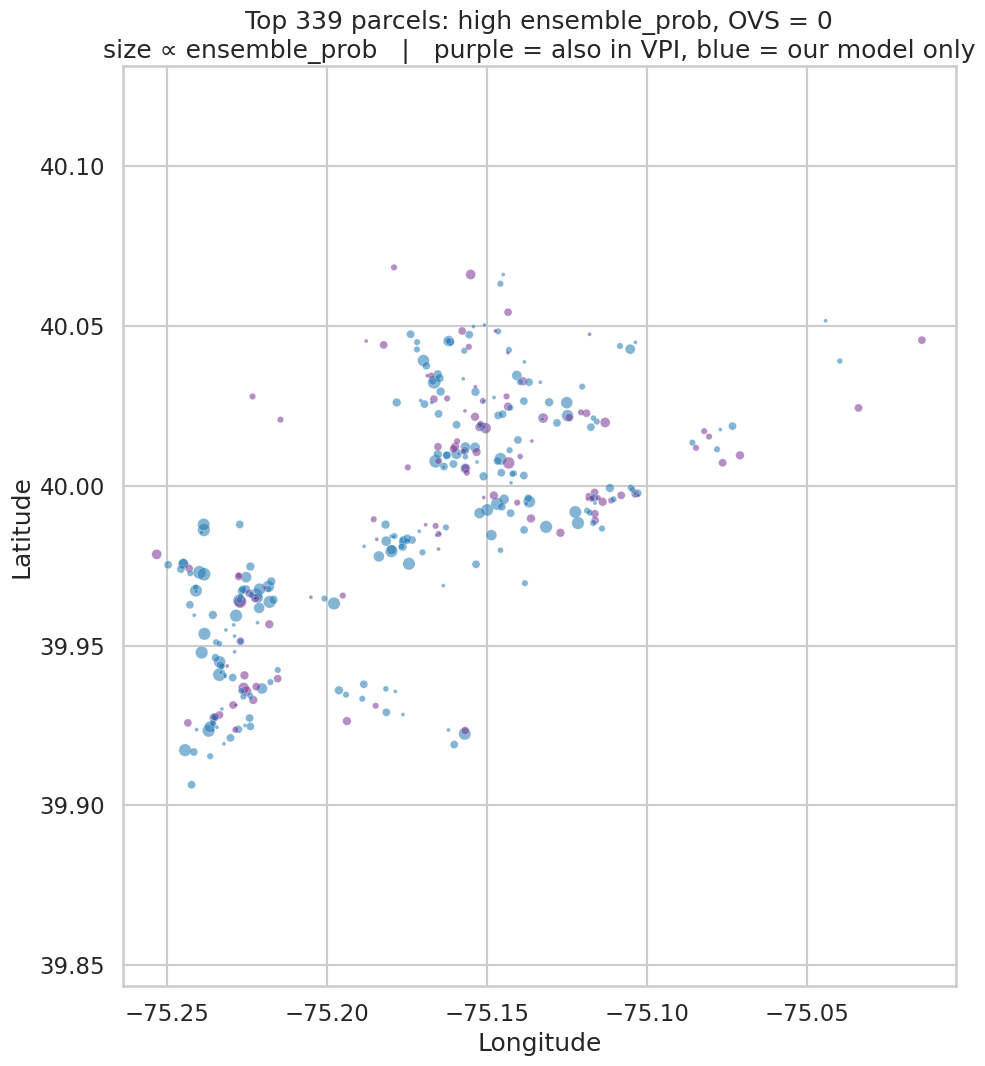

Exported 339 parcels -> /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_high_prob_ovs0.csv


In [48]:
# 11c. Static matplotlib version
fig, ax = plt.subplots(figsize=(10, 11))
sizes = 8 + 80 * (fp_map["ensemble_prob"] - p_min) / max(p_max - p_min, 1e-9)
colors = ["#7b3294" if v == 1 else "#1f78b4" for v in fp_map["vpi_flag"]]
ax.scatter(fp_map["lon"], fp_map["lat"], s=sizes, c=colors, alpha=0.55,
           edgecolors="white", linewidths=0.3)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Top {len(fp_map):,} parcels: high ensemble_prob, OVS = 0\n"
             f"size ∝ ensemble_prob   |   purple = also in VPI, blue = our model only")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.savefig(GRAPH_PATH / "vs_city_vpi_high_prob_ovs0_map.png", dpi=200, bbox_inches="tight")
plt.show()

# Export the parcel list for follow-up review
fp_map[["parcel_number", "zip_code", "category_code_description",
        "ovs", "ensemble_prob", "vpi_flag", "build_rank", "bucket",
        "lon", "lat"]].to_csv(OUT_PATH / "vs_city_vpi_high_prob_ovs0.csv", index=False)
print(f"Exported {len(fp_map):,} parcels -> {OUT_PATH / 'vs_city_vpi_high_prob_ovs0.csv'}")


## 12. Export

In [49]:
compare.to_csv(OUT_PATH / 'vs_city_vpi_headline.csv', index=False)
bucket_summary.to_csv(OUT_PATH / 'vs_city_vpi_buckets.csv', index=False)
zip_compare.to_csv(OUT_PATH / 'vs_city_vpi_zip.csv', index=False)

parcel_out = df[['parcel_number', 'zip_code', 'category_code_description',
                 'ovs', 'ensemble_prob', 'vpi_flag', 'build_rank',
                 'ours_bin', 'bucket']].copy()
parcel_out.to_csv(OUT_PATH / 'vs_city_vpi_parcel.csv', index=False)

print(f"Wrote:")
print(f"  {OUT_PATH / 'vs_city_vpi_headline.csv'}")
print(f"  {OUT_PATH / 'vs_city_vpi_buckets.csv'}")
print(f"  {OUT_PATH / 'vs_city_vpi_zip.csv'}")
print(f"  {OUT_PATH / 'vs_city_vpi_parcel.csv'} ({len(parcel_out):,} rows)")
print(f"  {OUT_PATH / 'vs_city_vpi_map.html'}  (interactive map)")
print(f"  {GRAPH_PATH / 'vs_city_vpi_map.png'}  (static map)")

Wrote:
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_headline.csv
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_buckets.csv
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_zip.csv
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_parcel.csv (520,196 rows)
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vs_city_vpi_map.html  (interactive map)
  /content/drive/MyDrive/PhillyStat_R/PhillyStat360/graphs/python/vs_city_vpi_map.png  (static map)


---
**Done.** All comparison artifacts live in `data_py/` with the `vs_city_vpi_` prefix.

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04c_vs_city_vpi.ipynb